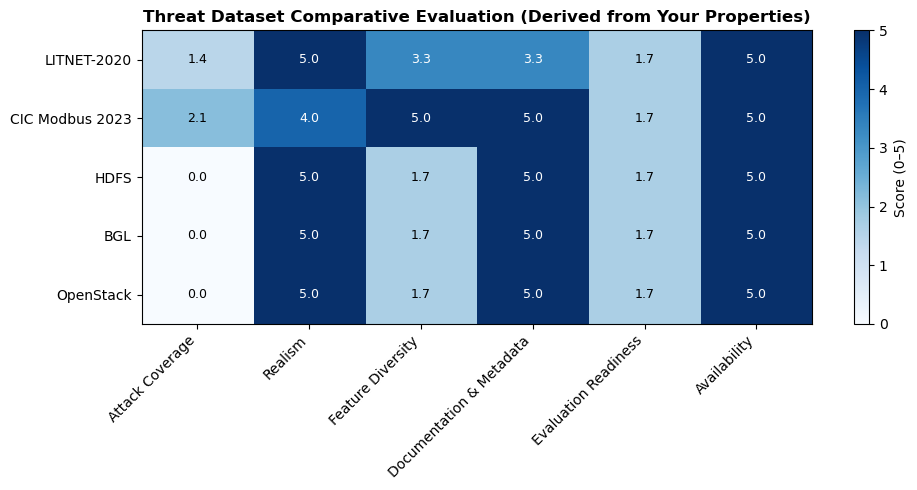

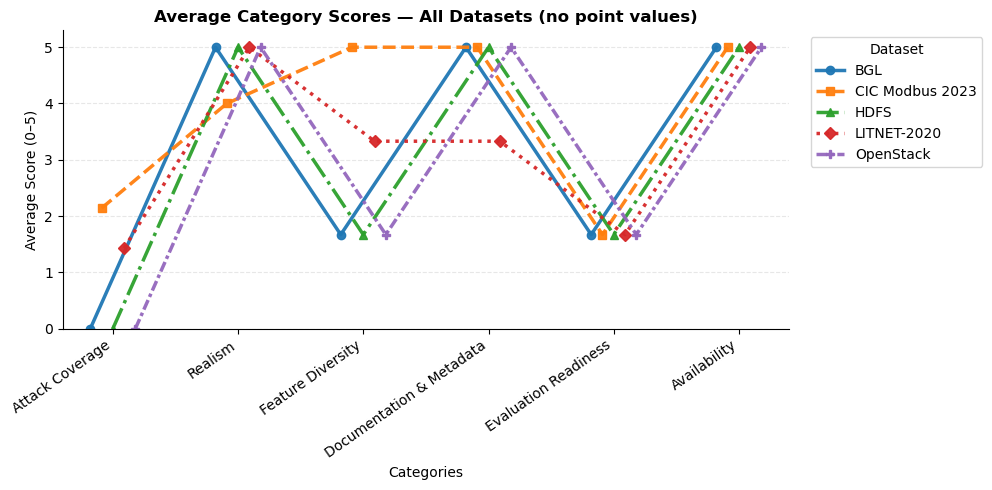

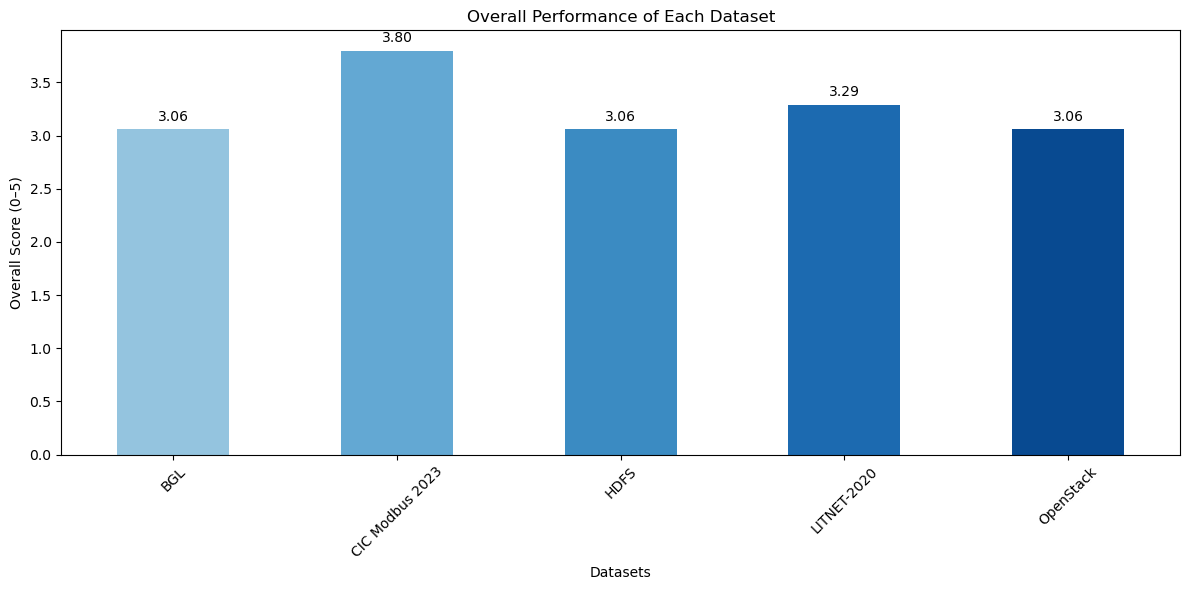

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 1) Load your property table ----------
src = Path("Full_Dataset.csv")
df = pd.read_csv(src)

# ---------- 2) Scoring rules ----------
ATTACK_COLS = ["DoS", "DDoS", "U2R", "R2L", "Password", "Injection", "Probe"]
FEATURE_COLS = ["Basic_Feature", "Traffic_Feature", "Content_Feature"]
EVAL_COLS    = ["Predefine_Split", "Balanced", "Labelled"]

def as_bool(x):
    if isinstance(x, str):
        t = x.strip().lower()
        if t in {"true","yes","y","1"}:   return True
        if t in {"false","no","n","0",""}: return False
    return bool(x)

def score_attack_coverage(r):
    present = sum(as_bool(r.get(c, False)) for c in ATTACK_COLS)
    return round(5 * present / len(ATTACK_COLS), 2)

def score_realism(r):
    base = {"real":5, "emulated":3, "synthetic":1}.get(str(r.get("Source","")).strip().lower(), 0)
    if as_bool(r.get("Regular_Traffic", False)):
        base += 1
    return float(min(5, base))

def score_feature_diversity(r):
    present = sum(as_bool(r.get(c, False)) for c in FEATURE_COLS)
    return round(5 * present / len(FEATURE_COLS), 2)

def score_metadata(r):
    checks = [
        int(str(r.get("Release_Year","")).strip() != ""),
        int(as_bool(r.get("Meta_Data", False))),
        int(str(r.get("Data_Format","")).strip() != "")
    ]
    return round(5 * sum(checks) / 3, 2)

def score_eval_readiness(r):
    present = sum(as_bool(r.get(c, False)) for c in EVAL_COLS)
    return round(5 * present / len(EVAL_COLS), 2)

def score_availability(r):
    return float({
        "public":5,
        "onrequest":3,
        "on request":3,
        "no":1
    }.get(str(r.get("Availability","")).strip().lower(), 0))

# ---------- 3) Build scoring table ----------
rows = []
for _, r in df.iterrows():
    s1 = score_attack_coverage(r)
    s2 = score_realism(r)
    s3 = score_feature_diversity(r)
    s4 = score_metadata(r)
    s5 = score_eval_readiness(r)
    s6 = score_availability(r)
    rows.append({
        "Dataset": r["Dataset"],
        "Attack Coverage": s1,
        "Realism": s2,
        "Feature Diversity": s3,
        "Documentation & Metadata": s4,
        "Evaluation Readiness": s5,
        "Availability": s6,
        "Overall (Mean)": round(np.mean([s1, s2, s3, s4, s5, s6]), 2)
    })

scores = pd.DataFrame(rows).set_index("Dataset")

# ---------- 4) Save ----------
out_csv = Path("dataset_scores_table.csv")
# scores.to_csv(out_csv)

# ---------- 5) Heatmap (blue; adaptive text colour) ----------
fig, ax = plt.subplots(figsize=(10, 5))
M = scores.drop(columns=["Overall (Mean)"]).values

cmap = plt.cm.Blues
im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=0, vmax=5)

ax.set_xticks(np.arange(M.shape[1]))
ax.set_xticklabels(scores.drop(columns=["Overall (Mean)"]).columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(scores.index)))
ax.set_yticklabels(scores.index)

# Normalize values to [0,1] for color comparison
norm = plt.Normalize(vmin=0, vmax=5)

# Add text annotations with contrast-aware colour
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        value = M[i, j]
        # Get background color from colormap
        bg_color = cmap(norm(value))
        # Decide text color based on brightness (luma)
        brightness = (0.299*bg_color[0] + 0.587*bg_color[1] + 0.114*bg_color[2])
        text_color = "white" if brightness < 0.5 else "black"
        ax.text(j, i, f"{value:.1f}", ha="center", va="center", color=text_color, fontsize=9)

ax.set_title("Threat Dataset Comparative Evaluation (Derived from Your Properties)", fontweight="bold")
fig.colorbar(im, ax=ax, label="Score (0–5)")
plt.tight_layout()
plt.show()


# ---------- 6) MULTI-LINE CHART: Average Category Scores — All Datasets (clean lines; no point values) ----------
category_scores = scores.drop(columns=["Overall (Mean)"]).groupby("Dataset").mean()
categories = list(category_scores.columns)
x = np.arange(len(categories))

ds_names = list(category_scores.index)
n = len(ds_names)
offsets = np.linspace(-0.18, 0.18, n)

markers = ['o', 's', '^', 'D', 'P', 'X', '*']
linestyles = ['-', '--', '-.', ':', (0,(3,1,1,1)), (0,(5,2))]

fig, ax = plt.subplots(figsize=(10, 5))
for i, ds in enumerate(ds_names):
    y = category_scores.loc[ds].values.astype(float)
    x_shift = x + offsets[i]
    ax.plot(x_shift, y,
            marker=markers[i % len(markers)],
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2.5, alpha=0.95, label=ds)

ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=35, ha="right")
ax.set_xlim(x.min() - 0.4, x.max() + 0.4)
ax.set_ylim(0, 5.3)
ax.set_ylabel("Average Score (0–5)")
ax.set_xlabel("Categories")
ax.set_title("Average Category Scores — All Datasets (no point values)", fontweight="bold")
ax.grid(True, axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(title="Dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------- 7) Overall performance bar chart (with numbers) ----------
overall_scores = scores.groupby("Dataset")["Overall (Mean)"].mean()
ax = overall_scores.plot(kind='bar', figsize=(12, 6),
                         color=plt.cm.Blues(np.linspace(0.4, 0.9, len(overall_scores))),
                         title='Overall Performance of Each Dataset')
plt.ylabel("Overall Score (0–5)")
plt.xlabel("Datasets")
plt.xticks(rotation=45)
for i, v in enumerate(overall_scores.values):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()
